# *Setup*

In [1]:
%%time
import numpy as np
import pandas as pd

from hid_avan.eda import head_tail_info, plot_basin_and_stations
from hid_avan.modeling import build_timeseries_df_from_monthly_pet

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='ticks')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'cm'

CPU times: total: 1.28 s
Wall time: 1.25 s


# Construindo a Série Temporal de Evapotranspirações Mensais através das Normais Climatológicas de Evapotranspirações Potenciais

## Selecionando a estação

In [6]:
df_stations = pd.read_excel('../../data/raw/Normal-Climatologica-ESTACOES.xlsx', header=2)

df_basin = pd.read_csv('../../data/raw/34750000.txt', header=None)
df_basin.rename({1:'Latitude', 0:'Longitude'}, axis='columns', inplace=True)

head_tail_info(df_stations, n=3)
head_tail_info(df_basin, n=3)

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Nº               267 non-null    int64         
 1   Código           267 non-null    int64         
 2   Nome da Estação  267 non-null    str           
 3   UF               267 non-null    str           
 4   Latitude         267 non-null    float64       
 5   Longitude        267 non-null    float64       
 6   Atitude          267 non-null    float64       
 7   Inicio Operação  267 non-null    object        
 8   Fim Operação     155 non-null    datetime64[us]
 9   Situação         267 non-null    str           
dtypes: datetime64[us](1), float64(3), int64(2), object(1), str(3)
memory usage: 21.0+ KB


,Nº,Código,Nome da Estação,UF,Latitude,Longitude,Atitude,Inicio Operação,Fim Operação,Situação
0,1,82704,CRUZEIRO DO SUL,AC,-7.610833,-72.681389,214.19,1928-01-01 00:00:00,2016-01-30,Desativada
1,2,82915,RIO BRANCO,AC,-9.959167,-67.868889,160.71,1929-01-01 00:00:00,2023-08-15,Fechada
2,3,82807,TARAUACÁ,AC,-8.160278,-70.768611,172.27,1966-06-06 00:00:00,NaT,Operante
264,265,83228,PEIXE,TO,-12.015278,-48.545000,252.24,1975-05-01 00:00:00,NaT,Operante
265,266,83064,PORTO NACIONAL,TO,-10.710833,-48.406389,243.28,1915-01-01 00:00:00,NaT,Operante
266,267,83235,TAGUATINGA,TO,-12.402222,-46.438333,604.88,1915-12-22 00:00:00,NaT,Operante


None

<class 'pandas.DataFrame'>
RangeIndex: 8090 entries, 0 to 8089
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  8090 non-null   float64
 1   Latitude   8090 non-null   float64
dtypes: float64(2)
memory usage: 126.5 KB


,Longitude,Latitude
0,-40.814582,-4.626249
1,-40.813749,-4.626249
2,-40.813749,-4.627083
8087,-40.813749,-4.624583
8088,-40.814582,-4.624583
8089,-40.814582,-4.626249


None

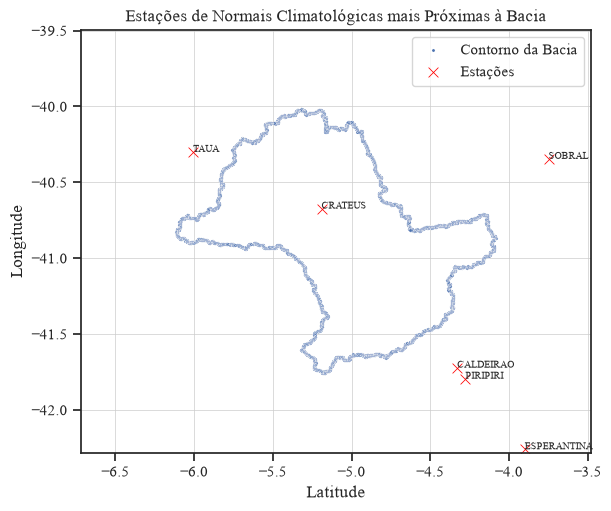

In [9]:
fig, ax = plot_basin_and_stations(df_basin=df_basin, df_stations=df_stations,
                                  factor_borders=.3, plot_text_col='Nome da Estação', special_points=None)
ax.set_title("Estações de Normais Climatológicas mais Próximas à Bacia")
plt.show()

## Extraindo o *dataset* da estação

In [10]:
df_normais = pd.read_excel('../../data/raw/49-Evapotranspiracao-Potencial-NCB_1981-2010.xls', header=3)
df_normais.rename({'Código ':'Código'}, axis='columns', inplace=True)
df_normais.where(df_normais != '-', np.nan, inplace=True)
df_normais = df_normais.astype( dict( zip( df_normais.columns[3:], ['float64']*13 ) ) )
head_tail_info(df_normais)

<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Código           310 non-null    int64  
 1   Nome da Estação  310 non-null    str    
 2   UF               310 non-null    str    
 3   Janeiro          307 non-null    float64
 4   Fevereiro        308 non-null    float64
 5   Março            310 non-null    float64
 6   Abril            310 non-null    float64
 7   Maio             308 non-null    float64
 8   Junho            308 non-null    float64
 9   Julho            308 non-null    float64
 10  Agosto           310 non-null    float64
 11  Setembro         308 non-null    float64
 12  Outubro          310 non-null    float64
 13  Novembro         310 non-null    float64
 14  Dezembro         308 non-null    float64
 15  Ano              297 non-null    float64
dtypes: float64(13), int64(1), str(2)
memory usage: 38.9 KB


,Código,Nome da Estação,UF,Janeiro,Fevereiro,Março,Abril,Maio,Junho,Julho,Agosto,Setembro,Outubro,Novembro,Dezembro,Ano
0,82704,CRUZEIRO DO SUL,AC,173.0,151.2,162.0,151.4,151.5,136.8,142.8,154.6,166.8,179.8,171.1,170.6,159.3
1,82915,RIO BRANCO,AC,165.9,144.4,159.1,145.6,141.0,119.9,128.6,152.4,169.9,182.7,171.0,166.6,153.9
2,82807,TARAUACA,AC,172.7,151.3,164.9,157.9,148.8,136.7,142.0,160.9,165.7,182.4,171.3,170.9,160.5
3,82989,AGUA BRANCA,AL,152.9,130.0,143.0,124.9,110.3,86.1,79.8,85.5,103.4,135.1,148.0,159.3,121.5
4,82994,MACEIO,AL,160.9,145.3,160.5,145.1,135.7,116.7,109.6,110.5,116.6,141.1,147.3,159.4,137.4
305,83033,PALMAS,TO,190.8,167.4,178.6,169.5,168.6,146.4,157.0,207.6,247.9,229.2,208.7,213.3,190.4
306,82863,PEDRO AFONSO,TO,175.3,157.9,165.3,160.1,158.4,139.4,143.9,176.2,200.3,202.7,186.2,182.3,170.7
307,83228,PEIXE,TO,184.1,163.7,168.5,157.6,152.0,123.4,128.0,175.2,207.6,221.0,200.5,192.5,172.8
308,83064,PORTO NACIONAL,TO,189.3,176.2,184.3,180.9,175.3,151.3,164.0,211.1,239.8,245.6,215.1,215.0,195.7
309,83235,TAGUATINGA,TO,169.6,151.7,152.8,142.5,138.0,122.8,133.8,176.9,208.0,221.5,189.5,181.4,165.7


None

In [11]:
display(df_normais.loc[df_normais['Nome da Estação'] == 'CRATEUS'])
pet_array = df_normais.loc[df_normais['Nome da Estação'] == 'CRATEUS', df_normais.columns[3:-1]].values.reshape(-1)
display(pet_array)

,Código,Nome da Estação,UF,Janeiro,Fevereiro,Março,Abril,Maio,Junho,Julho,Agosto,Setembro,Outubro,Novembro,Dezembro,Ano
56,82583,CRATEUS,CE,229.4,176.0,171.7,140.9,147.6,142.3,162.8,191.7,213.9,245.3,242.0,250.0,192.8


array([229.4, 176. , 171.7, 140.9, 147.6, 142.3, 162.8, 191.7, 213.9,
       245.3, 242. , 250. ])

In [12]:
df_et = build_timeseries_df_from_monthly_pet(pet_jan_to_dec=pet_array,
                                             date_start='1964-01-01', date_end='2026-07-31')
#df_et.to_csv('../../data/processed/timeseries_monthly_et.csv', index=False)
head_tail_info(df_et)

<class 'pandas.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    751 non-null    datetime64[us]
 1   et      751 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 11.9 KB


,date,et
0,1964-01-01,229.4
1,1964-02-01,176.0
2,1964-03-01,171.7
3,1964-04-01,140.9
4,1964-05-01,147.6
746,2026-03-01,171.7
747,2026-04-01,140.9
748,2026-05-01,147.6
749,2026-06-01,142.3
750,2026-07-01,162.8


None